In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import requests
import re
import string

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

In [3]:
# get raw text of the Time Machine by H.G. Wells
url = 'https://www.gutenberg.org/files/35/35-0.txt'
response = requests.get(url)
text = response.text

# character strings to replace with spaces
strings2replace = ['\r\n\r\nâ\x80\x9c',
                   'â\x80\x9c',
                   'â\x80\x9d',
                   '\r\n',
                   'â\x80\x94',
                   'â\x80\x99',
                   'â\x80\x98','_', ]

# here we are cleaning the text, but normally this is done by the tokenizer
for str2match in strings2replace:
    text = re.sub(str2match, ' ', text) # using regex to replace all occurrences of the string with a space

# remove non-ASCII characters
text = re.sub(r'[^\x00-\x7F]+', ' ', text)

text = re.sub(r'\d+','',text) # remove digits

# make everything lowercase
text = text.lower()

In [4]:
# regex pattern to split by punctuation and whitespace, \s matches any whitespace character, + means one or more occurrences
regex_pattern_split = rf'[{string.punctuation}\s]+' 
words = re.split(regex_pattern_split, text)

# strip() removes leading and trailing whitespace from each word, and we also filter out empty strings
words = [item.strip() for item in words if item.strip() != ''] # remove empty strings and strip whitespace

# remove single character words, just for convenience, but this is not necessary for tokenization
words = [word for word in words if len(word) > 1]

# create a set of unique words to build the vocabulary
vocab = set(words)
n_words = len(words)
n_vocab = len(vocab)
print(f"Total number of words: {n_words}")
print(f"Vocabulary size: {n_vocab}")

# encoder / decoder dictionaries to map words to integers and vice versa
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

# show some examples of the mapping
print("\nExample word to index mapping:")
for word in list(vocab)[:10]:
    print(f"{word}: {word2idx[word]}")

Total number of words: 30698
Vocabulary size: 4589

Example word to index mapping:
attentively: 0
agony: 1
halls: 2
far: 3
casting: 4
labours: 5
why: 6
crystal: 7
hillyer: 8
follow: 9


In [5]:
# parameters for dataset
context_size = 8 # how many words to consider after the target word (in this case we are not considering the words before the target word)
stride = 2 # how many words to skip between contexts

# inputs and targets for the dataset
inputs = []
targets = []

# loop through the words and create contexts and targets
for i in range(0, len(words) - context_size, stride):
    context = words[i:i+context_size] # get the context of words
    target = words[i+1:i+context_size+1] # we could use the next word, or as in this case the next 8 words as targets
    inputs.append([word2idx[word] for word in context]) # convert context words to indices
    targets.append([word2idx[word] for word in target]) # convert target words to indices

len(inputs), len(targets), len(words) # inputs is half of words since we are using a stride of 2.

(15345, 15345, 30698)

In [6]:
# do the same but using unfold
indices = [word2idx[word] for word in words]  # convert all text to indices once
tensor = torch.tensor(indices, dtype=torch.long)
inputs_unfold = tensor.unfold(0, context_size, stride)  # create contexts using unfold
targets_unfold = tensor[1:].unfold(0, context_size, stride)    # shifted by 1

# make sure both have the same number of windows
min_len = min(len(inputs_unfold), len(targets_unfold))
inputs_unfold = inputs_unfold[:min_len]
targets_unfold = targets_unfold[:min_len]

print(torch.all(inputs_unfold == torch.tensor(inputs)))  # should be True
print(torch.all(targets_unfold == torch.tensor(targets)))  # should be True
len(inputs_unfold), len(targets_unfold), len(words)

tensor(True)
tensor(True)


(15345, 15345, 30698)

In [7]:
class WordDataset(Dataset):
    def __init__(self, words, word2idx, context_size=8, stride=2):
        indices = [word2idx[word] for word in words]  # convert all text to indices once
        tensor = torch.tensor(indices, dtype=torch.long)

        # build all windows at once using unfold
        self.inputs  = tensor.unfold(0, context_size, stride)       # (num_windows, context_size)
        self.targets = tensor[1:].unfold(0, context_size, stride)    # shifted by 1

        # make sure both have the same number of windows
        min_len = min(len(self.inputs), len(self.targets))
        self.inputs  = self.inputs[:min_len]
        self.targets = self.targets[:min_len]

    def __len__(self):
        return len(self.inputs)  # number of windows, not tokens

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]  # each is (context_size,)

In [8]:
# create an instance of the dataset
context_size = 6
stride = 3
text_dataset = WordDataset(words, word2idx, context_size=context_size, stride=stride)
print(f"Number of samples in dataset: {len(text_dataset)}")

Number of samples in dataset: 10231


In [9]:
# we also need a dataloader to iterate through the dataset in batches
batch_size = 32
text_dataloader = DataLoader(text_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# let's have a look at the first batch of inputs and targets
X_batch, y_batch = next(iter(text_dataloader))
print(f"Input batch shape: {X_batch.shape}")  # should be (batch_size, context_size)
print(f"Target batch shape: {y_batch.shape}")  # should be (batch_size, context_size)

# print the first words in the first input and target batch to verify
input_words = [idx2word[idx.item()] for idx in X_batch[0]]
target_words = [idx2word[idx.item()] for idx in y_batch[0]]
print(f"Input: {input_words} -> Target: {target_words}")

Input batch shape: torch.Size([32, 6])
Target batch shape: torch.Size([32, 6])
Input: ['smoke', 'in', 'moment', 'was', 'wet', 'to'] -> Target: ['in', 'moment', 'was', 'wet', 'to', 'the']


In [10]:
# create an embedding layer to convert word indices to embeddings
embedding_dim = 100 # we can choose any embedding dimension, but 100 is fine for small datasets.

# create a random embedding layer that maps each word index to a vector of size embedding_dim
embedding_layer = nn.Embedding(n_vocab, embedding_dim) # (4589, 100) since we have 4589 unique words in the vocabulary

In [11]:
# create a class for the language model
class SimpleLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super(SimpleLanguageModel, self).__init__()

        # embedding layer to convert word indices to embeddings (for example token 1234 will be mapped to a vector of size embedding_dim)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # linear layers
        self.fc1 = nn.Linear(embedding_dim * context_size, 128)
        self.fc2 = nn.Linear(128, vocab_size)

    def forward(self, x):
        # x: (batch_size, context_size) — token indices

        embedded = self.embedding(x) # each token index is mapped to a vector of size embedding_dim
        # embedded: (batch_size, context_size, embedding_dim)

        embedded = embedded.view(x.size(0), -1)
        # embedded: (batch_size, context_size * embedding_dim) — flattened the 2nd and 3rd dimensions

        out = F.relu(self.fc1(embedded))
        # out: (batch_size, 128)

        out = self.fc2(out)
        # out: (batch_size, vocab_size) — raw logits
        # we are only predicting the next word, so we will apply softmax to get probabilities, 
        # but we will do that later when we train the model, since the loss function (CrossEntropyLoss) expects raw logits.
        
        return out

# function to apply Xavier normal initialization to the model's weights, linear layers and embedding layer
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Embedding):
        nn.init.xavier_normal_(m.weight)

model = SimpleLanguageModel(n_vocab, embedding_dim, context_size)
model.apply(init_weights)
print(model)

SimpleLanguageModel(
  (embedding): Embedding(4589, 100)
  (fc1): Linear(in_features=600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4589, bias=True)
)


In [12]:
# let's test the model
X_batch, y_batch = next(iter(text_dataloader))
print(f"Input batch shape: {X_batch.shape}")  # should be (batch_size, context_size)
logits = model(X_batch)
print(f"Output shape: {logits.shape}")  # should be (batch_size, vocab_size)

Input batch shape: torch.Size([32, 6])
Output shape: torch.Size([32, 4589])


In [13]:
# let's predict one word for one sequence in the batch
X_batch, _ = next(iter(text_dataloader))
input_indices = X_batch[0]  # get the first sequence in the batch, shape (context_size,)
input_words = [idx2word[idx.item()] for idx in input_indices]
print(f"Input words: {input_words}")

# get the logits for the first sequence in the batch
logits = model(input_indices.unsqueeze(0)) # (1, context_size) -> (1, vocab_size)
print(f"input_indices.unsqueeze(0) shape: {input_indices.unsqueeze(0).shape}")
print(f"Logits shape: {logits.shape}")

# # we can apply log_softmax to the output to get probabilities
log_probs = F.log_softmax(logits, dim=1) # (1, vocab_size)
print(f"Log probabilities shape: {log_probs.shape}")

# get the one with the highest probability for each position in the context
predicted_index = torch.argmax(log_probs, dim=1)
predicted_words = idx2word[predicted_index.item()]
print(f"Predicted words: {predicted_words}")

Input words: ['had', 'such', 'profound', 'sense', 'of', 'desertion']
input_indices.unsqueeze(0) shape: torch.Size([1, 6])
Logits shape: torch.Size([1, 4589])
Log probabilities shape: torch.Size([1, 4589])
Predicted words: shock


In [14]:
torch.max(log_probs, dim=1)[0]

tensor([-8.3255], grad_fn=<MaxBackward0>)

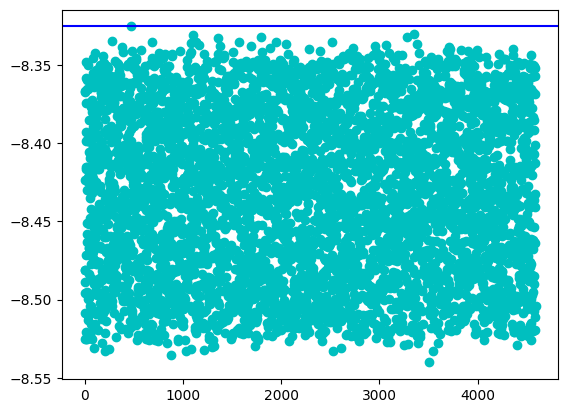

In [15]:
plt.plot(log_probs.detach().numpy().T, 'co'); # we plot all the log probabilities for each word in the vocabulary (size 4589)
plt.axhline(
    torch.max(log_probs, dim=1)[0].detach().numpy(), 
    color='blue', 
    markersize=10, 
    label='Max Log Probability'
); 
# we are picking the one with the highest probability, but in reality they are all very close, since we haven't trained the model, so the predictions are basically random.

In [16]:
# how the text generation loop works:
X_batch, y_batch = next(iter(text_dataloader)) # get a batch of data

# tested only on the first sequence
X_batch_0 = X_batch[0] # shape (context_size,)
print(f"First input sequence: {[idx2word[idx.item()] for idx in X_batch_0]}")

for _ in range(context_size): # we will generate context_size words
    logits = model(X_batch_0.unsqueeze(0)) # get the output logits for the current batch
    log_probs = F.log_softmax(logits, dim=1) # convert to log probabilities
    predicted_index = torch.argmax(log_probs, dim=1) # get the predicted indices for the next word
    predicted_word = idx2word[predicted_index.item()]
    print(f"Predicted word: {predicted_word}")
    
    # now we need to update X_batch_0 by removing the first word and adding the predicted word at the end of the context
    X_batch_0 = torch.cat([X_batch_0[1:], predicted_index])
    print(f"Updated input sequence: {[idx2word[idx.item()] for idx in X_batch_0]}")

First input sequence: ['and', 'put', 'these', 'in', 'my', 'pocket']
Predicted word: balloon
Updated input sequence: ['put', 'these', 'in', 'my', 'pocket', 'balloon']
Predicted word: shock
Updated input sequence: ['these', 'in', 'my', 'pocket', 'balloon', 'shock']
Predicted word: luminous
Updated input sequence: ['in', 'my', 'pocket', 'balloon', 'shock', 'luminous']
Predicted word: overworlders
Updated input sequence: ['my', 'pocket', 'balloon', 'shock', 'luminous', 'overworlders']
Predicted word: rolling
Updated input sequence: ['pocket', 'balloon', 'shock', 'luminous', 'overworlders', 'rolling']
Predicted word: wisely
Updated input sequence: ['balloon', 'shock', 'luminous', 'overworlders', 'rolling', 'wisely']


In [17]:
summary(model, input_data=X_batch, col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SimpleLanguageModel                      [32, 6]                   [32, 4589]                --
├─Embedding: 1-1                         [32, 6]                   [32, 6, 100]              458,900
├─Linear: 1-2                            [32, 600]                 [32, 128]                 76,928
├─Linear: 1-3                            [32, 128]                 [32, 4589]                591,981
Total params: 1,127,809
Trainable params: 1,127,809
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 36.09
Input size (MB): 0.00
Forward/backward pass size (MB): 1.36
Params size (MB): 4.51
Estimated Total Size (MB): 5.87

In [18]:
loss_fn = nn.CrossEntropyLoss() # since it is the same as NLLLoss but with log_softmax included
#loss_fn = nn.NLLLoss() # we can also use NLLLoss but then we need to apply log_softmax to the output of the model before passing it to the loss function

# test the loss function with the model's output and the target
logits = model(X_batch) # (batch_size, vocab_size)

# no need to apply log_softmax since CrossEntropyLoss expects raw logits, but if we were using NLLLoss we would need to apply log_softmax here

# we will only use the last word in the target sequence for simplicity, shape (batch_size,)
# since even we create the targets as the next 8 words, we are only predicting the next word in the model we created,
#  so we will use the last word in the target sequence as the true label for the prediction.
targets = y_batch[:, -1] # (batch_size,)
loss = loss_fn(logits, targets)
print(f"Loss: {loss.item()}")

Loss: 8.430089950561523


In [19]:
# create an optimizer to update the model's parameters
model = SimpleLanguageModel(n_vocab, embedding_dim, context_size)
model.apply(init_weights) # apply Xavier normal initialization to the model's weights
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
num_epochs = 25

loss_history = np.zeros(num_epochs) # to store the loss for each epoch

pre_trained_embeddings = model.embedding.weight.detach().clone() # we can save the initial random embeddings to compare later after training

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in text_dataloader:
        optimizer.zero_grad() # zero the gradients from the previous step

        logits = model(X_batch) # get the model's predictions
        targets = y_batch[:, -1] # get the true labels (last word in the target sequence)
        loss = loss_fn(logits, targets) # compute the loss
        loss.backward() # backpropagate to compute gradients
        optimizer.step() # update the model's parameters

        total_loss += loss.item() # accumulate the loss for this epoch
        
    avg_loss = total_loss / len(text_dataloader) # average loss for this epoch
    loss_history[epoch] = avg_loss
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

post_trained_embeddings = model.embedding.weight.detach().clone() # we can save the final embeddings after training to compare with the initial random embeddings

Epoch 1/25, Loss: 6.9431
Epoch 2/25, Loss: 6.0316
Epoch 3/25, Loss: 5.6273
Epoch 4/25, Loss: 5.2826
Epoch 5/25, Loss: 4.9356
Epoch 6/25, Loss: 4.5742
Epoch 7/25, Loss: 4.1607
Epoch 8/25, Loss: 3.7037
Epoch 9/25, Loss: 3.1976
Epoch 10/25, Loss: 2.6309
Epoch 11/25, Loss: 2.0170
Epoch 12/25, Loss: 1.4108
Epoch 13/25, Loss: 0.8690
Epoch 14/25, Loss: 0.4822
Epoch 15/25, Loss: 0.2537
Epoch 16/25, Loss: 0.1317
Epoch 17/25, Loss: 0.0720
Epoch 18/25, Loss: 0.0431
Epoch 19/25, Loss: 0.0290
Epoch 20/25, Loss: 0.0191
Epoch 21/25, Loss: 0.0154
Epoch 22/25, Loss: 0.0116
Epoch 23/25, Loss: 0.0117
Epoch 24/25, Loss: 0.0094
Epoch 25/25, Loss: 0.0079


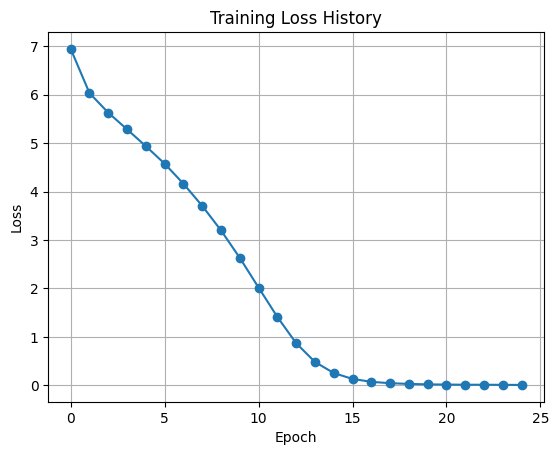

In [20]:
# plot the loss history
plt.plot(loss_history, 'o-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

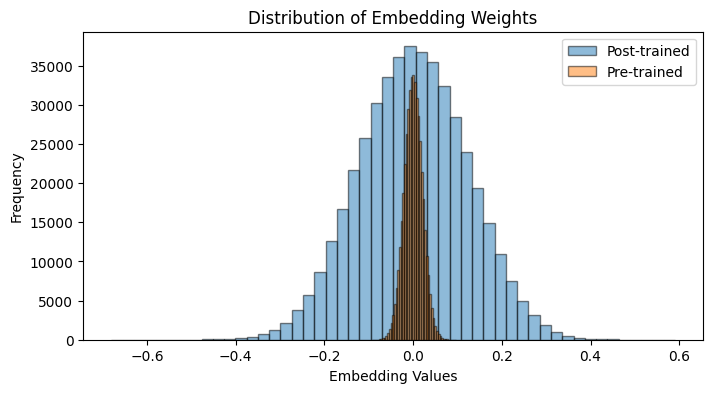

In [21]:
# plot both the pre-trained and post-trained embeddings matrices weight distribution
y_pre, x_pre = np.histogram(pre_trained_embeddings.flatten(), bins=50)
y_post, x_post = np.histogram(post_trained_embeddings.flatten(), bins=50)

# recalculate the bin centers for better plotting
x_pre_centers = (x_pre[:-1] + x_pre[1:]) / 2
x_post_centers = (x_post[:-1] + x_post[1:]) / 2

plt.figure(figsize=(8, 4))
plt.bar(x_post_centers, y_post, width=(x_post[1] - x_post[0]), alpha=0.5, label='Post-trained', edgecolor='black');
plt.bar(x_pre_centers, y_pre, width=(x_pre[1] - x_pre[0]), alpha=0.5, label='Pre-trained', edgecolor='black')
plt.xlabel('Embedding Values')
plt.ylabel('Frequency')
plt.title('Distribution of Embedding Weights')
plt.legend()
plt.show()

# pre-trained is very narrow and centered around 0, while post-trained is much wider and has more extreme values, 
# which is expected since the model has learned to adjust the embeddings to better fit the data, while the pre-trained 
# embeddings are just random values initialized with Xavier normal initialization.

Cosine similarity between 'time' and 'machine' before training: 0.1040
Cosine similarity between 'time' and 'machine' after training: 0.2462


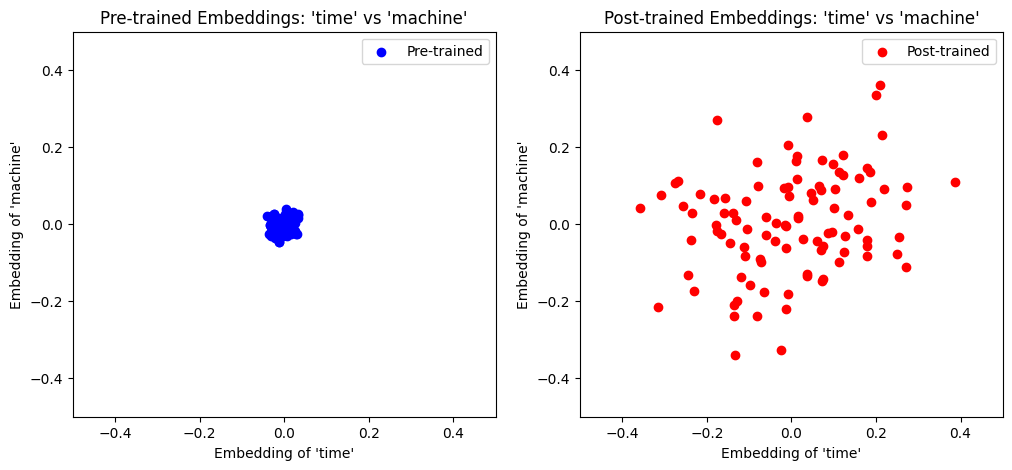

In [ ]:
# cosine similarity between the pre-trained and post-trained embeddings for a few random words
word1 = 'time'
word2 = 'machine'

# their indices
idx1 = word2idx[word1]
idx2 = word2idx[word2]

# their embeddings
embedding_pre_word1 = pre_trained_embeddings[idx1]
embedding_pre_word2 = pre_trained_embeddings[idx2]
embedding_post_word1 = post_trained_embeddings[idx1]
embedding_post_word2 = post_trained_embeddings[idx2]

# cosine similarity function
cos_sim_pre = F.cosine_similarity(embedding_pre_word1.unsqueeze(0), embedding_pre_word2.unsqueeze(0)).item()
cos_sim_post = F.cosine_similarity(embedding_post_word1.unsqueeze(0), embedding_post_word2.unsqueeze(0)).item()
print(f"Cosine similarity between '{word1}' and '{word2}' before training: {cos_sim_pre:.4f}")
print(f"Cosine similarity between '{word1}' and '{word2}' after training: {cos_sim_post:.4f}")

# visualize of both words 1 vs 2
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(embedding_pre_word1.detach().numpy(), embedding_pre_word2.detach().numpy(), color='blue', label='Pre-trained')
axs[1].scatter(embedding_post_word1.detach().numpy(), embedding_post_word2.detach().numpy(), color='red', label='Post-trained')
axs[0].set_title(f"Pre-trained Embeddings: '{word1}' vs '{word2}'")
axs[1].set_title(f"Post-trained Embeddings: '{word1}' vs '{word2}'")
axs[0].set_xlabel(f"Embedding of '{word1}'")
axs[0].set_ylabel(f"Embedding of '{word2}'")
axs[1].set_xlabel(f"Embedding of '{word1}'")
axs[1].set_ylabel(f"Embedding of '{word2}'")
axs[0].set_xlim(-0.5, 0.5)
axs[0].set_ylim(-0.5, 0.5)
axs[1].set_xlim(-0.5, 0.5)
axs[1].set_ylim(-0.5, 0.5)
axs[0].legend()
axs[1].legend()
plt.show()

# The embeddings vectors expanded to fill up more of the embeddings space, reflecting encoding of high-dimensional semantic information
# in a lower-dimensional space, while the pre-trained embeddings are just random values that are more clustered around 0. 
# The cosine similarity between the two words also changed after training, which indicates that the interpretable semantic relationships
# emerge even with a small dataset and a simple model, which is one of the key properties of word embeddings.